In [1]:
import sys
print(sys.executable)

C:\football_transfer_analysis\venv\Scripts\python.exe


In [9]:
import duckdb

con = duckdb.connect('C:/football_transfer_analysis/data/transfermarkt-datasets.duckdb')
con.execute("SHOW TABLES").df()

,name
0,appearances
1,club_games
2,clubs
3,competitions
4,countries
5,game_events
6,game_lineups
7,games
8,national_teams
9,player_valuations


In [10]:
tables = con.execute("SHOW TABLES").df()
print(tables)

for t in tables['name']:
    print(f"\n--- {t} ---")
    print(con.execute(f"DESCRIBE {t}").df())
    print(con.execute(f"SELECT COUNT(*) as row_count FROM {t}").df())

                 name
0         appearances
1          club_games
2               clubs
3        competitions
4           countries
5         game_events
6        game_lineups
7               games
8      national_teams
9   player_valuations
10            players
11          transfers
12            version

--- appearances ---
               column_name column_type null   key default extra
0            appearance_id     VARCHAR  YES  None    None  None
1                  game_id     INTEGER  YES  None    None  None
2                player_id     INTEGER  YES  None    None  None
3           player_club_id     INTEGER  YES  None    None  None
4   player_current_club_id     VARCHAR  YES  None    None  None
5                     date        DATE  YES  None    None  None
6              player_name     VARCHAR  YES  None    None  None
7           competition_id     VARCHAR  YES  None    None  None
8             yellow_cards     INTEGER  YES  None    None  None
9                red_cards     

In [12]:
con.execute('SELECT* FROM players limit 10').df()

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,<NA>,<NA>,None,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000,30000000
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,<NA>,<NA>,None,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000,8000000
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,<NA>,<NA>,None,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000,34500000
3,77,NaN,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,...,NaN,https://img.a.transfermarkt.technology/portrai...,<NA>,<NA>,None,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus FC,200000,24500000
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,IFM,https://img.a.transfermarkt.technology/portrai...,<NA>,<NA>,None,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,Bayern Munich,100000,3000000
5,109,NaN,Dedê,Dedê,2013,825,dede,Brazil,Belo Horizonte,Brazil,...,Football Concept,https://img.a.transfermarkt.technology/portrai...,<NA>,<NA>,None,https://www.transfermarkt.co.uk/dede/profil/sp...,TR1,Eskisehirspor,400000,9500000
6,123,Christoph,Metzelder,Christoph Metzelder,2012,33,christoph-metzelder,Germany,Haltern,Germany,...,NaN,https://img.a.transfermarkt.technology/portrai...,<NA>,<NA>,None,https://www.transfermarkt.co.uk/christoph-metz...,L1,FC Schalke 04,1500000,9500000
7,132,Tomas,Rosicky,Tomas Rosicky,2015,11,tomas-rosicky,CSSR,Praha,Czech Republic,...,NaN,https://img.a.transfermarkt.technology/portrai...,<NA>,<NA>,None,https://www.transfermarkt.co.uk/tomas-rosicky/...,GB1,Arsenal FC,350000,17500000
8,162,Marc,Ziegler,Marc Ziegler,2012,79,marc-ziegler,Germany,Blieskastel,Germany,...,NaN,https://img.a.transfermarkt.technology/portrai...,<NA>,<NA>,None,https://www.transfermarkt.co.uk/marc-ziegler/p...,L1,VfB Stuttgart,200000,1250000
9,215,Roque,Santa Cruz,Roque Santa Cruz,2015,1084,roque-santa-cruz,Paraguay,Asunción,Paraguay,...,NaN,https://img.a.transfermarkt.technology/portrai...,<NA>,<NA>,None,https://www.transfermarkt.co.uk/roque-santa-cr...,ES1,Málaga CF,250000,12000000


In [16]:
con.execute("""
    SELECT MIN(date) as earliest ,MAX (date)as latest,COUNT(*) as rows FROM player_valuations """).df()

,earliest,latest,rows
0,2000-01-20,2026-02-27,507815


In [19]:
con.execute("""
    SELECT MIN(date) as earliest ,MAX (date)as latest,COUNT(DISTINCT player_id) as players  FROM appearances """).df()

,earliest,latest,players
0,2012-07-03,2026-06-28,29531


In [20]:
query = """
CREATE OR REPLACE TABLE player_season_stats AS
SELECT
    a.player_id,
    p.name,
    p.position,
    p.sub_position,
    p.date_of_birth,
    EXTRACT(YEAR FROM a.date) as season_year,
    COUNT(DISTINCT a.game_id) as appearances_count,
    SUM(a.goals) as total_goals,
    SUM(a.assists) as total_assists,
    SUM(a.minutes_played) as total_minutes,
    SUM(a.yellow_cards) as total_yellows,
    SUM(a.red_cards) as total_reds
FROM appearances a
JOIN players p ON a.player_id = p.player_id
WHERE a.date >= '2018-01-01'
GROUP BY a.player_id, p.name, p.position, p.sub_position, p.date_of_birth, EXTRACT(YEAR FROM a.date)
"""
con.execute(query)

con.execute("SELECT COUNT(*) as row_count, COUNT(DISTINCT player_id) as unique_players FROM player_season_stats").df()

,row_count,unique_players
0,73145,21983


In [21]:
query = """
CREATE OR REPLACE TABLE player_season_value AS
SELECT
    pss.*,
    pv.market_value_in_eur
FROM player_season_stats pss
LEFT JOIN LATERAL (
    SELECT market_value_in_eur
    FROM player_valuations pv
    WHERE pv.player_id = pss.player_id
      AND EXTRACT(YEAR FROM pv.date) = pss.season_year
    ORDER BY pv.date DESC
    LIMIT 1
) pv ON true
"""
con.execute(query)

con.execute("""
    SELECT COUNT(*) as total_rows,
           COUNT(market_value_in_eur) as rows_with_value,
           COUNT(*) - COUNT(market_value_in_eur) as missing_value
    FROM player_season_value
""").df()

,total_rows,rows_with_value,missing_value
0,73145,58918,14227


In [22]:
query = """
CREATE OR REPLACE TABLE player_features AS
SELECT
    *,
    ROUND(total_goals * 90.0 / NULLIF(total_minutes, 0), 3) as goals_per_90,
    ROUND(total_assists * 90.0 / NULLIF(total_minutes, 0), 3) as assists_per_90,
    ROUND((total_goals + total_assists) * 90.0 / NULLIF(total_minutes, 0), 3) as goal_contributions_per_90,
    DATE_DIFF('year', date_of_birth, MAKE_DATE(season_year, 6, 1)) as age_at_season
FROM player_season_value
WHERE market_value_in_eur IS NOT NULL
  AND total_minutes >= 450  -- filter out tiny sample sizes (roughly 5 full matches minimum)
"""
con.execute(query)

con.execute("SELECT COUNT(*) as final_row_count FROM player_features").df()

,final_row_count
0,40684


In [23]:
con.execute("""
    SELECT
        MIN(market_value_in_eur) as min_val,
        MAX(market_value_in_eur) as max_val,
        AVG(market_value_in_eur) as avg_val,
        MEDIAN(market_value_in_eur) as median_val
    FROM player_features
""").df()

,min_val,max_val,avg_val,median_val
0,25000,200000000,6.451604e+06,1800000.0


In [24]:
query = """
CREATE OR REPLACE TABLE player_model_data AS
SELECT
    *,
    LN(market_value_in_eur) as log_market_value
FROM player_features
"""
con.execute(query)

con.execute("""
    SELECT player_id, name, position, season_year, age_at_season,
           goals_per_90, assists_per_90, total_minutes,
           market_value_in_eur, log_market_value
    FROM player_model_data
    ORDER BY market_value_in_eur DESC
    LIMIT 10
""").df()

,player_id,name,position,season_year,age_at_season,goals_per_90,assists_per_90,total_minutes,market_value_in_eur,log_market_value
0,342229,Kylian Mbappé,Attack,2019,21,1.214,0.383,2818.0,200000000,19.113828
1,342229,Kylian Mbappé,Attack,2018,20,0.741,0.353,2550.0,200000000,19.113828
2,418560,Erling Haaland,Attack,2025,25,0.964,0.193,3736.0,200000000,19.113828
3,418560,Erling Haaland,Attack,2024,24,0.819,0.043,4176.0,200000000,19.113828
4,581678,Jude Bellingham,Midfield,2024,21,0.328,0.353,3566.0,180000000,19.008467
5,342229,Kylian Mbappé,Attack,2024,26,0.753,0.215,3345.0,180000000,19.008467
6,342229,Kylian Mbappé,Attack,2022,24,1.041,0.406,3545.0,180000000,19.008467
7,581678,Jude Bellingham,Midfield,2023,20,0.572,0.234,3461.0,180000000,19.008467
8,342229,Kylian Mbappé,Attack,2020,22,0.827,0.472,2286.0,180000000,19.008467
9,371998,Vinicius Junior,Attack,2024,24,0.744,0.384,3748.0,180000000,19.008467


In [25]:
query = """
CREATE OR REPLACE TABLE player_model_data AS
SELECT
    pf.*,
    LN(pf.market_value_in_eur) as log_market_value,
    ROUND(pf.total_yellows * 90.0 / NULLIF(pf.total_minutes, 0), 3) as yellows_per_90,
    ROUND(pf.total_reds * 90.0 / NULLIF(pf.total_minutes, 0), 3) as reds_per_90,
    CASE WHEN pf.position = 'Attack' THEN 1 ELSE 0 END as pos_attack,
    CASE WHEN pf.position = 'Midfield' THEN 1 ELSE 0 END as pos_midfield,
    CASE WHEN pf.position = 'Defender' THEN 1 ELSE 0 END as pos_defender,
    CASE WHEN pf.position = 'Goalkeeper' THEN 1 ELSE 0 END as pos_goalkeeper,
    p.foot,
    p.international_caps,
    p.height_in_cm
FROM player_features pf
JOIN players p ON pf.player_id = p.player_id
"""
con.execute(query)

con.execute("SELECT position, COUNT(*) as n FROM player_model_data GROUP BY position").df()

,position,n
0,Goalkeeper,3260
1,Attack,10546
2,Midfield,11965
3,Defender,14899
4,Missing,14


In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

df = con.execute("SELECT * FROM player_model_data").df()

features = [
    'age_at_season', 'goals_per_90', 'assists_per_90', 'goal_contributions_per_90',
    'total_minutes', 'yellows_per_90', 'reds_per_90',
    'pos_attack', 'pos_midfield', 'pos_defender', 'pos_goalkeeper',
    'international_caps', 'height_in_cm'
]
target = 'log_market_value'

model_df = df[features + [target, 'player_id', 'name', 'season_year']].dropna()

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MAE (log scale):", mean_absolute_error(y_test, y_pred))
print("Training rows:", len(X_train), "| Test rows:", len(X_test))

R²: 0.4139212451661095
MAE (log scale): 0.9248984804762578
Training rows: 20043 | Test rows: 5011


In [28]:
coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_
}).sort_values('coefficient', ascending=False)

print("Intercept:", model.intercept_)
coef_df


Intercept: 14.619164841747649


,feature,coefficient
3,goal_contributions_per_90,0.776504
6,reds_per_90,0.643042
2,assists_per_90,0.471661
1,goals_per_90,0.304841
8,pos_midfield,0.116479
9,pos_defender,0.022933
11,international_caps,0.014247
12,height_in_cm,0.006524
4,total_minutes,0.000749
7,pos_attack,-0.004468


In [29]:
features_v2 = [
    'age_at_season', 'goals_per_90', 'assists_per_90',
    'total_minutes', 'yellows_per_90', 'reds_per_90',
    'pos_attack', 'pos_midfield', 'pos_defender', 'pos_goalkeeper',
    'international_caps', 'height_in_cm'
]

model_df_v2 = df[features_v2 + [target, 'player_id', 'name', 'season_year']].dropna()
X2 = model_df_v2[features_v2]
y2 = model_df_v2[target]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

model_v2 = LinearRegression()
model_v2.fit(X_train2, y_train2)
y_pred2 = model_v2.predict(X_test2)

print("R²:", r2_score(y_test2, y_pred2))
print("MAE (log scale):", mean_absolute_error(y_test2, y_pred2))

coef_df_v2 = pd.DataFrame({
    'feature': features_v2,
    'coefficient': model_v2.coef_
}).sort_values('coefficient', ascending=False)
coef_df_v2

R²: 0.41392300759138567
MAE (log scale): 0.9249020898692946


,feature,coefficient
2,assists_per_90,1.248252
1,goals_per_90,1.081419
5,reds_per_90,0.643075
7,pos_midfield,0.116478
8,pos_defender,0.022937
10,international_caps,0.014247
11,height_in_cm,0.006525
3,total_minutes,0.000749
6,pos_attack,-0.004492
0,age_at_season,-0.105050


In [30]:
con.execute("""
    SELECT 
        CASE WHEN reds_per_90 > 0 THEN 'has_red' ELSE 'no_red' END as red_group,
        COUNT(*) as n,
        AVG(market_value_in_eur) as avg_value,
        AVG(total_minutes) as avg_minutes
    FROM player_model_data
    WHERE reds_per_90 IS NOT NULL
    GROUP BY red_group
""").df()

,red_group,n,avg_value,avg_minutes
0,no_red,37603,6.375016e+06,1598.655187
1,has_red,3081,7.386352e+06,1896.150276


In [31]:
features_v3 = [
    'age_at_season', 'goals_per_90', 'assists_per_90',
    'total_minutes', 'yellows_per_90',
    'pos_attack', 'pos_midfield', 'pos_defender', 'pos_goalkeeper',
    'international_caps', 'height_in_cm'
]

model_df_v3 = df[features_v3 + [target, 'player_id', 'name', 'season_year']].dropna()
X3 = model_df_v3[features_v3]
y3 = model_df_v3[target]

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.2, random_state=42)

model_v3 = LinearRegression()
model_v3.fit(X_train3, y_train3)
y_pred3 = model_v3.predict(X_test3)

print("R²:", r2_score(y_test3, y_pred3))
print("MAE (log scale):", mean_absolute_error(y_test3, y_pred3))

coef_df_v3 = pd.DataFrame({
    'feature': features_v3,
    'coefficient': model_v3.coef_
}).sort_values('coefficient', ascending=False)
coef_df_v3

R²: 0.4138243472218348
MAE (log scale): 0.925030866537701


,feature,coefficient
2,assists_per_90,1.247762
1,goals_per_90,1.081062
6,pos_midfield,0.116646
7,pos_defender,0.023915
9,international_caps,0.014248
10,height_in_cm,0.006542
3,total_minutes,0.000748
5,pos_attack,-0.004559
0,age_at_season,-0.105004
8,pos_goalkeeper,-0.136002


In [34]:
import numpy as np
model_df_v3 = model_df_v3.copy()
model_df_v3['predicted_log_value'] = model_v3.predict(X3)
model_df_v3['predicted_value_eur'] = np.exp(model_df_v3['predicted_log_value'])
model_df_v3['actual_value_eur'] = np.exp(model_df_v3[target])

model_df_v3['residual'] = model_df_v3[target] - model_df_v3['predicted_log_value']
model_df_v3['value_ratio'] = model_df_v3['predicted_value_eur'] / model_df_v3['actual_value_eur']

undervalued = model_df_v3[model_df_v3['season_year'] == 2025].sort_values('residual', ascending=False).head(25)

undervalued[['name', 'age_at_season', 'goals_per_90', 'assists_per_90', 
             'actual_value_eur', 'predicted_value_eur', 'value_ratio']]

,name,age_at_season,goals_per_90,assists_per_90,actual_value_eur,predicted_value_eur,value_ratio
10156,Rodri,29,0.000,0.151,75000000.0,1.991934e+06,0.026559
38163,Bremer,28,0.000,0.300,35000000.0,1.055956e+06,0.030170
9716,Ben White,28,0.000,0.148,30000000.0,1.307885e+06,0.043596
37630,Vitor Roque,20,0.128,0.000,35000000.0,1.569053e+06,0.044830
7103,Danilo,24,0.000,0.000,22000000.0,1.038560e+06,0.047207
37612,Sven Botman,25,0.000,0.000,35000000.0,1.706349e+06,0.048753
32609,Rico Henry,28,0.000,0.000,15000000.0,7.743066e+05,0.051620
37635,Diogo Jota,29,0.287,0.096,40000000.0,2.074336e+06,0.051858
32717,Wesley Fofana,25,0.000,0.074,28000000.0,1.521083e+06,0.054324
40214,Axel Disasi,27,0.000,0.000,15000000.0,8.170201e+05,0.054468


In [39]:
undervalued = model_df_v3[
    (model_df_v3['season_year'] == 2025) &
    (model_df_v3['position'].isin(['Attack', 'Midfield']))
].sort_values('residual', ascending=True).head(25)

undervalued[['name', 'position', 'age_at_season', 'goals_per_90', 'assists_per_90',
             'actual_value_eur', 'predicted_value_eur', 'value_ratio']]

undervalued[['name', 'position', 'age_at_season', 'goals_per_90', 'assists_per_90',
             'actual_value_eur', 'predicted_value_eur', 'value_ratio']]

,name,position,age_at_season,goals_per_90,assists_per_90,actual_value_eur,predicted_value_eur,value_ratio
12118,Junior Hoilett,Attack,35,0.436,0.262,50000.0,2.142120e+06,42.842400
20040,Ivan Perišić,Attack,36,0.457,0.430,1300000.0,5.317485e+07,40.903733
21546,Osman Kaynak,Attack,19,0.000,0.187,75000.0,1.786514e+06,23.820184
20088,João Moutinho,Midfield,39,0.029,0.116,500000.0,1.168966e+07,23.379314
23230,Salih Kavrazlı,Attack,23,0.552,0.184,150000.0,2.746943e+06,18.312955
7640,Oleg Pushkaryov,Attack,21,0.140,0.210,200000.0,3.327699e+06,16.638496
5920,Martin Boyle,Attack,32,0.533,0.089,500000.0,7.982592e+06,15.965184
16874,Idrissa Gueye,Midfield,36,0.055,0.083,1000000.0,1.593911e+07,15.939111
13822,Ivan Losenko,Midfield,21,0.043,0.043,300000.0,4.744413e+06,15.814710
13685,Josh Mulligan,Midfield,23,0.049,0.196,1200000.0,1.718172e+07,14.318101


In [40]:
'current_club_domestic_competition_id' in df.columns

False

In [41]:
league_lookup = con.execute("""
    SELECT player_id, current_club_domestic_competition_id
    FROM players
""").df()

df = df.merge(league_lookup, on='player_id', how='left')

'current_club_domestic_competition_id' in df.columns


True

In [42]:
top5_leagues = ['GB1', 'ES1', 'IT1', 'L1', 'FR1']

df['is_top5_league'] = df['current_club_domestic_competition_id'].isin(top5_leagues).astype(int)

df[['name', 'current_club_domestic_competition_id', 'is_top5_league']].drop_duplicates(subset='name').head(10)

,name,current_club_domestic_competition_id,is_top5_league
0,Nathan Aké,GB1,1
1,Harry Arter,GB1,1
2,Adam Smith,GB1,1
3,Emre Can,L1,1
4,Sadio Mané,SA1,0
5,Trent Alexander-Arnold,ES1,1
6,Steven Defour,BE1,0
7,Dejan Lovren,GR1,0
8,Wayne Rooney,GB1,1
9,Marcos Rojo,ARG1,0


In [43]:
features_v4 = [
    'age_at_season', 'goals_per_90', 'assists_per_90',
    'total_minutes', 'yellows_per_90',
    'pos_attack', 'pos_midfield', 'pos_defender', 'pos_goalkeeper',
    'international_caps', 'height_in_cm', 'is_top5_league'
]

model_df_v4 = df[features_v4 + [target, 'player_id', 'name', 'season_year', 'position']].dropna()

X4 = model_df_v4[features_v4]
y4 = model_df_v4[target]

X_train4, X_test4, y_train4, y_test4 = train_test_split(X4, y4, test_size=0.2, random_state=42)

model_v4 = LinearRegression()
model_v4.fit(X_train4, y_train4)
y_pred4 = model_v4.predict(X_test4)

print("R²:", r2_score(y_test4, y_pred4))
print("MAE (log scale):", mean_absolute_error(y_test4, y_pred4))

coef_df_v4 = pd.DataFrame({
    'feature': features_v4,
    'coefficient': model_v4.coef_
}).sort_values('coefficient', ascending=False)
coef_df_v4

R²: 0.5394670812372295
MAE (log scale): 0.7952092443284018


,feature,coefficient
2,assists_per_90,1.158449
11,is_top5_league,1.130663
1,goals_per_90,1.051057
6,pos_midfield,0.109577
5,pos_attack,0.012184
9,international_caps,0.012111
7,pos_defender,0.001883
3,total_minutes,0.000628
10,height_in_cm,-0.000331
0,age_at_season,-0.084171


In [44]:
model_df_v4 = model_df_v4.copy()
model_df_v4['predicted_log_value'] = model_v4.predict(X4)
model_df_v4['predicted_value_eur'] = np.exp(model_df_v4['predicted_log_value'])
model_df_v4['actual_value_eur'] = np.exp(model_df_v4[target])
model_df_v4['residual'] = model_df_v4[target] - model_df_v4['predicted_log_value']
model_df_v4['value_ratio'] = model_df_v4['predicted_value_eur'] / model_df_v4['actual_value_eur']

undervalued_v2 = model_df_v4[
    (model_df_v4['season_year'] == 2025) &
    (model_df_v4['position'].isin(['Attack', 'Midfield']))
].sort_values('residual', ascending=True).head(25)

undervalued_v2[['name', 'position', 'age_at_season', 'goals_per_90', 'assists_per_90',
                'actual_value_eur', 'predicted_value_eur', 'value_ratio']]

,name,position,age_at_season,goals_per_90,assists_per_90,actual_value_eur,predicted_value_eur,value_ratio
19757,Junior Hoilett,Attack,35,0.436,0.262,50000.0,1.741262e+06,34.825235
27480,Idrissa Gueye,Midfield,36,0.055,0.083,1000000.0,2.711286e+07,27.112858
32590,Ivan Perišić,Attack,36,0.457,0.430,1300000.0,2.499092e+07,19.223783
35028,Osman Kaynak,Attack,19,0.000,0.187,75000.0,1.292745e+06,17.236603
32646,João Moutinho,Midfield,39,0.029,0.116,500000.0,7.030197e+06,14.060393
9569,Luka Modrić,Midfield,40,0.136,0.191,4000000.0,5.503720e+07,13.759300
37724,Salih Kavrazlı,Attack,23,0.552,0.184,150000.0,1.981464e+06,13.209757
2082,Jae-sung Lee,Midfield,33,0.161,0.193,2000000.0,2.385874e+07,11.929371
24919,Mathieu Valbuena,Midfield,41,0.136,0.271,50000.0,5.522496e+05,11.044992
30112,Andrej Kramaric,Attack,34,0.300,0.433,3000000.0,3.310192e+07,11.033973


In [45]:
df['age_squared'] = df['age_at_season'] ** 2

features_v5 = [
    'age_at_season', 'age_squared', 'goals_per_90', 'assists_per_90',
    'total_minutes', 'yellows_per_90',
    'pos_attack', 'pos_midfield', 'pos_defender', 'pos_goalkeeper',
    'international_caps', 'height_in_cm', 'is_top5_league'
]

model_df_v5 = df[features_v5 + [target, 'player_id', 'name', 'season_year', 'position']].dropna()

X5 = model_df_v5[features_v5]
y5 = model_df_v5[target]

X_train5, X_test5, y_train5, y_test5 = train_test_split(X5, y5, test_size=0.2, random_state=42)

model_v5 = LinearRegression()
model_v5.fit(X_train5, y_train5)
y_pred5 = model_v5.predict(X_test5)

print("R²:", r2_score(y_test5, y_pred5))
print("MAE (log scale):", mean_absolute_error(y_test5, y_pred5))

coef_df_v5 = pd.DataFrame({
    'feature': features_v5,
    'coefficient': model_v5.coef_
}).sort_values('coefficient', ascending=False)
coef_df_v5

R²: 0.5694145684751375
MAE (log scale): 0.7722934407833186


,feature,coefficient
3,assists_per_90,1.194646
12,is_top5_league,1.152143
2,goals_per_90,1.042763
0,age_at_season,0.558421
7,pos_midfield,0.088248
10,international_caps,0.013137
4,total_minutes,0.000589
11,height_in_cm,-0.000861
6,pos_attack,-0.009331
8,pos_defender,-0.010669


In [46]:
model_df_v5 = model_df_v5.copy()
model_df_v5['predicted_log_value'] = model_v5.predict(X5)
model_df_v5['predicted_value_eur'] = np.exp(model_df_v5['predicted_log_value'])
model_df_v5['actual_value_eur'] = np.exp(model_df_v5[target])
model_df_v5['residual'] = model_df_v5[target] - model_df_v5['predicted_log_value']
model_df_v5['value_ratio'] = model_df_v5['predicted_value_eur'] / model_df_v5['actual_value_eur']

undervalued_v3 = model_df_v5[
    (model_df_v5['season_year'] == 2025) &
    (model_df_v5['position'].isin(['Attack', 'Midfield']))
].sort_values('residual', ascending=True).head(25)

undervalued_v3[['name', 'position', 'age_at_season', 'goals_per_90', 'assists_per_90',
                'actual_value_eur', 'predicted_value_eur', 'value_ratio']]


,name,position,age_at_season,goals_per_90,assists_per_90,actual_value_eur,predicted_value_eur,value_ratio
19757,Junior Hoilett,Attack,35,0.436,0.262,50000.0,9.507896e+05,19.015793
37724,Salih Kavrazlı,Attack,23,0.552,0.184,150000.0,2.155667e+06,14.371111
27480,Idrissa Gueye,Midfield,36,0.055,0.083,1000000.0,1.192899e+07,11.928986
35028,Osman Kaynak,Attack,19,0.000,0.187,75000.0,8.143589e+05,10.858119
2082,Jae-sung Lee,Midfield,33,0.161,0.193,2000000.0,1.855363e+07,9.276817
12335,Oleg Pushkaryov,Attack,21,0.140,0.210,200000.0,1.830980e+06,9.154898
32590,Ivan Perišić,Attack,36,0.457,0.430,1300000.0,1.098589e+07,8.450683
9557,Martin Boyle,Attack,32,0.533,0.089,500000.0,4.202603e+06,8.405206
14697,Roland Idowu,Midfield,23,0.235,0.000,150000.0,1.169964e+06,7.799758
9552,Finlay Robertson,Midfield,23,0.053,0.212,300000.0,2.311107e+06,7.703690


In [47]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Save the trained model
joblib.dump(model_v5, '../models/transfer_value_model_v5.pkl')

# Save the feature list (you'll need this exact order to use the model later)
joblib.dump(features_v5, '../models/features_v5.pkl')

# Save the full dataset with predictions back into DuckDB for persistence
con.execute("""
    CREATE OR REPLACE TABLE player_predictions AS
    SELECT * FROM model_df_v5
""")

# Also export a clean CSV snapshot of the undervalued list, useful for the dashboard later
undervalued_v3.to_csv('../data/undervalued_players_v1.csv', index=False)

print("Model saved to ../models/transfer_value_model_v5.pkl")
print("Predictions saved to DuckDB table: player_predictions")
print("Undervalued list exported to ../data/undervalued_players_v1.csv")

Model saved to ../models/transfer_value_model_v5.pkl
Predictions saved to DuckDB table: player_predictions
Undervalued list exported to ../data/undervalued_players_v1.csv


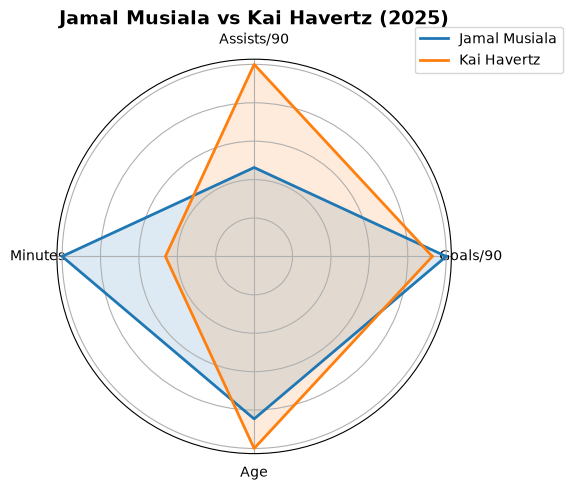

         name position  age_at_season  goals_per_90  assists_per_90  actual_value_eur  predicted_value_eur
Jamal Musiala Midfield             22         0.457           0.131       130000000.0         1.481667e+07
  Kai Havertz   Attack             26         0.424           0.283        55000000.0         1.073795e+07


In [51]:
import matplotlib.pyplot as plt
import numpy as np

def compare_players(name1, name2, season=2025):
    df = con.execute(f"""
        SELECT name, position, age_at_season, goals_per_90, assists_per_90,
               total_minutes, actual_value_eur, predicted_value_eur
        FROM player_predictions
        WHERE name IN ('{name1}', '{name2}') AND season_year = {season}
    """).df()
    
    if len(df) < 2:
        print("Couldn't find both players for that season — check spelling or try another year.")
        return df

    stats = ['goals_per_90', 'assists_per_90', 'total_minutes', 'age_at_season']
    labels = ['Goals/90', 'Assists/90', 'Minutes', 'Age']

    # Normalize each stat 0-1 across the two so the radar shape is meaningful
    norm_df = df.copy()
    for s in stats:
        max_val = df[s].max()
        norm_df[s] = df[s] / max_val if max_val > 0 else 0

    angles = np.linspace(0, 2 * np.pi, len(stats), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    for i, row in norm_df.iterrows():
        values = row[stats].tolist()
        values += values[:1]
        ax.plot(angles, values, label=df.iloc[i]['name'], linewidth=2)
        ax.fill(angles, values, alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels([])
    ax.set_title(f"{name1} vs {name2} ({season})", size=14, weight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

    # Also print the value comparison as a table underneath
    print(df[['name', 'position', 'age_at_season', 'goals_per_90', 'assists_per_90',
               'actual_value_eur', 'predicted_value_eur']].to_string(index=False))

compare_players('Jamal Musiala', 'Kai Havertz')

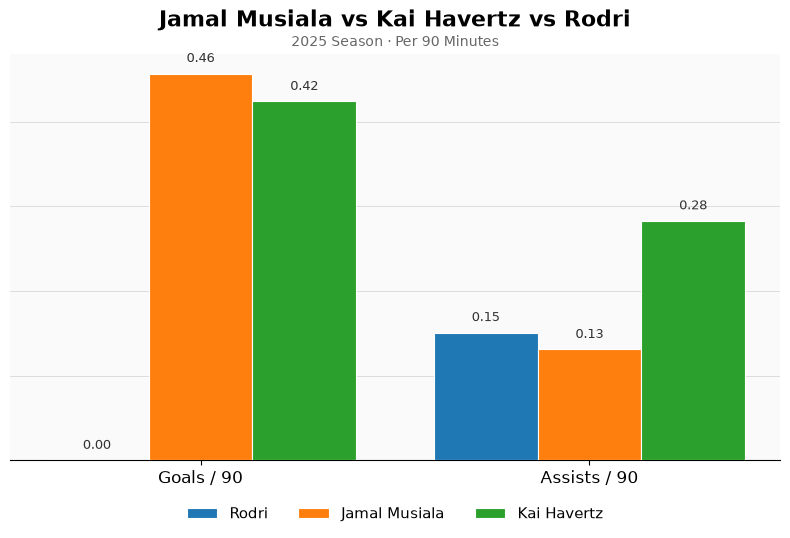

       Player Position  Age  Minutes Actual Value (€) Predicted Value (€)
        Rodri Midfield   29    595.0      €75,000,000          €5,187,497
Jamal Musiala Midfield   22   1379.0     €130,000,000         €14,816,673
  Kai Havertz   Attack   26    637.0      €55,000,000         €10,737,949


In [55]:
def compare_players(names, season=2025):
    placeholders = ", ".join([f"'{n}'" for n in names])
    df = con.execute(f"""
        SELECT name, position, age_at_season, goals_per_90, assists_per_90,
               total_minutes, actual_value_eur, predicted_value_eur
        FROM player_predictions
        WHERE name IN ({placeholders}) AND season_year = {season}
    """).df()

    if len(df) < 2:
        print("Need at least 2 matching players — check spelling or try another season.")
        return df

    stats = ['goals_per_90', 'assists_per_90']
    labels = ['Goals / 90', 'Assists / 90']

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    x = np.arange(len(stats))
    width = 0.8 / len(df)

    plt.style.use('default')
    fig, ax = plt.subplots(figsize=(8, 5.5))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('#fafafa')

    for i, row in df.iterrows():
        offset = (i - (len(df)-1)/2) * width
        bars = ax.bar(x + offset, row[stats].values, width,
                       label=row['name'], color=colors[i % len(colors)],
                       edgecolor='white', linewidth=0.8, zorder=3)
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                     f'{height:.2f}', ha='center', va='bottom',
                     fontsize=9, color='#333333')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=12, fontweight='medium')
    ax.set_title(f"{' vs '.join(names)}", fontsize=16, fontweight='bold', pad=20)
    ax.text(0.5, 1.02, f"{season} Season · Per 90 Minutes", transform=ax.transAxes,
            ha='center', fontsize=10, color='#666666')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.grid(axis='y', color='#dddddd', linewidth=0.7, zorder=0)
    ax.tick_params(left=False)
    ax.set_yticklabels([])

    ax.legend(frameon=False, fontsize=11, loc='upper center',
              bbox_to_anchor=(0.5, -0.08), ncol=len(df))

    plt.tight_layout()
    plt.show()

    display_df = df[['name', 'position', 'age_at_season', 'total_minutes',
                      'actual_value_eur', 'predicted_value_eur']].copy()
    display_df.columns = ['Player', 'Position', 'Age', 'Minutes', 'Actual Value (€)', 'Predicted Value (€)']
    display_df['Actual Value (€)'] = display_df['Actual Value (€)'].apply(lambda x: f'€{x:,.0f}')
    display_df['Predicted Value (€)'] = display_df['Predicted Value (€)'].apply(lambda x: f'€{x:,.0f}')
    print(display_df.to_string(index=False))

compare_players(['Jamal Musiala', 'Kai Havertz', 'Rodri'])